<a href="https://colab.research.google.com/github/moises-rb/customer-segmentation-platform/blob/main/notebooks/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Estrutura do notebook narrativo

1.  Configuração — preparando o ambiente
2.  Introdução — contexto e objetivo
3.  O dataset — quem são os dados
4.  Principais achados do EDA
5.  Pipeline de limpeza — o que foi feito e por quê
6.  RFM — construindo o coração do projeto
7.  Segmentação — os 4 perfis de cliente
8.  Predição de churn — o modelo
9.  Resultados finais — narrativa de negócio
10.  Como usar o pipeline

---

In [1]:
import os
import sys

# ── 1. Clonar o repositório ────────────────────────────────────
REPO = 'customer-segmentation-platform'

if not os.path.exists(REPO):
    !git clone https://github.com/moises-rb/{REPO}.git

# Garantir que está na raiz correta
os.chdir(f'/content/{REPO}')
sys.path.insert(0, '/content/{REPO}')

# ── 2. Instalar dependências ───────────────────────────────────
!pip install -q pandas numpy matplotlib seaborn scikit-learn openpyxl

# ── 3. Criar estrutura de pastas ───────────────────────────────
for pasta in ['data/raw', 'data/processed', 'data/features', 'models']:
    os.makedirs(pasta, exist_ok=True)

# ── 4. Baixar o dataset direto do UCI ─────────────────────────
import urllib.request, zipfile, glob

dataset_path = 'data/raw/online_retail_II.xlsx'

if not os.path.exists(dataset_path):
    print("Baixando dataset do UCI...")
    url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
    urllib.request.urlretrieve(url, 'data/raw/dataset.zip')
    with zipfile.ZipFile('data/raw/dataset.zip', 'r') as z:
        z.extractall('data/raw/')
    xlsx = glob.glob('data/raw/*.xlsx')[0]
    os.rename(xlsx, dataset_path)
    print(f"Dataset salvo em {dataset_path}")
else:
    print(f"Dataset já existe em {dataset_path}")

# ── 5. Confirmar localização ───────────────────────────────────
print(f"\nDiretório atual: {os.getcwd()}")
print(f"Arquivos src/: {os.listdir('src')}")
print("\nAmbiente pronto!")

Cloning into 'customer-segmentation-platform'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 26 (delta 2), reused 26 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 15.57 KiB | 549.00 KiB/s, done.
Resolving deltas: 100% (2/2), done.
Baixando dataset do UCI...
Dataset salvo em data/raw/online_retail_II.xlsx

Diretório atual: /content/customer-segmentation-platform
Arquivos src/: ['evaluation.py', 'prediction.py', 'pipeline.py', 'feature_engineering.py', 'preprocessing.py', 'segmentation.py']

Ambiente pronto!


# 🎯 Customer Segmentation Prediction Platform

## Contexto

E-commerces enfrentam um desafio silencioso: **não saber quem são seus clientes**.

Sem essa visão, toda campanha de marketing trata o cliente VIP que compra todo mês
igual ao cliente que comprou uma vez há dois anos e nunca mais voltou.

Este projeto resolve esse problema construindo uma plataforma que:
- Segmenta automaticamente os clientes em 4 perfis comportamentais
- Prediz quais clientes estão em risco de churn
- Recomenda estratégias de vendas personalizadas por perfil

**Dataset:** UCI Online Retail II — ~1 milhão de transações reais de e-commerce britânico  
**Período:** Dezembro/2009 a Dezembro/2011  
**Stack:** Python · Pandas · Scikit-learn · Streamlit

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.preprocessing import load_data, clean_data
from src.feature_engineering import calculate_rfm, apply_log_transform
from src.segmentation import scale_features, train_kmeans, assign_segments
from src.prediction import (create_churn_label, prepare_features,
                             scale_features as scale_pred,
                             train_model, evaluate_model, predict_churn)
from src.evaluation import segment_report, churn_report
from sklearn.model_selection import train_test_split

pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

CORES = {
    'VIP':       '#2ecc71',
    'Promissor': '#3498db',
    'Em Risco':  '#e67e22',
    'Perdido':   '#e74c3c'
}

print("Ambiente configurado!")

Ambiente configurado!


## 📦 O Dataset

O **UCI Online Retail II** contém transações reais de um e-commerce britânico
entre Dezembro/2009 e Dezembro/2011.

Antes de qualquer análise, o pipeline de limpeza remove ruídos do dataset:
- Duplicatas, cancelamentos e ajustes contábeis
- Registros sem Customer ID (transações anônimas)
- StockCodes operacionais que não são produtos reais
- Outliers de quantidade acima do percentil 99

**Resultado:** de 1.067.371 transações brutas → 770.715 transações válidas

---

In [5]:
print("Carregando e limpando os dados...")
df = load_data('data/raw/online_retail_II.xlsx')
df = clean_data(df)

print(f"✅ Dataset limpo: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"📅 Período: {df['InvoiceDate'].min().date()} até {df['InvoiceDate'].max().date()}")
print(f"👥 Clientes únicos: {df['Customer ID'].nunique():,}")
print(f"🛍️  Produtos únicos: {df['StockCode'].nunique():,}")
print(f"📋 Pedidos únicos: {df['Invoice'].nunique():,}")

Carregando e limpando os dados...
✅ Dataset limpo: 770,715 linhas x 9 colunas
📅 Período: 2009-12-01 até 2011-12-09
👥 Clientes únicos: 5,816
🛍️  Produtos únicos: 4,613
📋 Pedidos únicos: 35,946


## 📅 Comportamento Temporal

Antes de segmentar, entender **quando** os clientes compram revela o perfil do negócio
e orienta as estratégias de retenção.

---

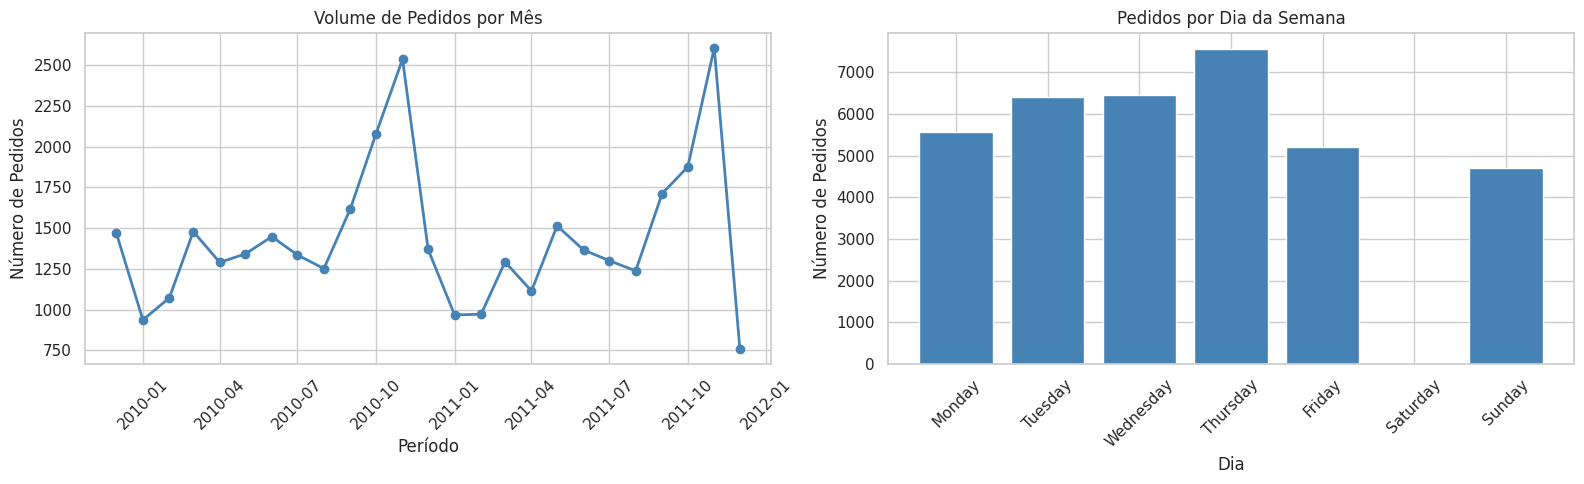


💡 Insight: Negócio B2B confirmado — zero pedidos no fim de semana
💡 Insight: Pico em Novembro — Black Friday + pré-Natal


In [6]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Sazonalidade mensal
transacoes_mes = df.groupby(['Year','Month'])['Invoice'].nunique().reset_index()
transacoes_mes['Periodo'] = pd.to_datetime(
    transacoes_mes['Year'].astype(str) + '-' +
    transacoes_mes['Month'].astype(str), format='%Y-%m'
)
axes[0].plot(transacoes_mes['Periodo'], transacoes_mes['Num_Pedidos']
             if 'Num_Pedidos' in transacoes_mes.columns
             else transacoes_mes['Invoice'],
             marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Volume de Pedidos por Mês')
axes[0].set_xlabel('Período')
axes[0].set_ylabel('Número de Pedidos')
axes[0].tick_params(axis='x', rotation=45)

# Pedidos por dia da semana
ordem_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pedidos_dia = df.groupby('DayOfWeek')['Invoice'].nunique().reindex(ordem_dias)
axes[1].bar(pedidos_dia.index, pedidos_dia.values, color='steelblue')
axes[1].set_title('Pedidos por Dia da Semana')
axes[1].set_xlabel('Dia')
axes[1].set_ylabel('Número de Pedidos')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 Insight: Negócio B2B confirmado — zero pedidos no fim de semana")
print("💡 Insight: Pico em Novembro — Black Friday + pré-Natal")

## 🧠 Feature Engineering — RFM

O RFM é a base da segmentação. Três perguntas simples que revelam
o comportamento completo de um cliente:

| Métrica | Pergunta | Sinal |
|---------|----------|-------|
| **Recency** | Quando comprou pela última vez? | Quanto menor, melhor |
| **Frequency** | Quantas vezes comprou? | Quanto maior, melhor |
| **Monetary** | Quanto gastou no total? | Quanto maior, melhor |

---

In [7]:
rfm = calculate_rfm(df)
rfm_log = apply_log_transform(rfm)

print(f"✅ RFM calculado para {len(rfm):,} clientes")
print(f"\nDistribuição das métricas:")
print(rfm[['Recency','Frequency','Monetary']].describe().round(2))

✅ RFM calculado para 5,816 clientes

Distribuição das métricas:
       Recency  Frequency  Monetary
count  5816.00    5816.00   5816.00
mean    200.53       6.18   2464.30
std     208.65      12.46   8744.73
min       1.00       1.00      2.90
25%      26.00       1.00    330.69
50%      95.00       3.00    829.12
75%     379.00       7.00   2143.36
max     739.00     373.00 336091.92


## 🎯 Segmentação — K-Means

Com o RFM calculado, aplicamos **K-Means** para agrupar clientes
com comportamento similar.

Antes do agrupamento, duas transformações são necessárias:
1. **Log** — comprime as caudas longas do RFM
2. **StandardScaler** — coloca as 3 métricas na mesma escala

O número ideal de clusters foi definido pelo **Método Elbow: k=4**,
resultando em 4 segmentos com interpretação clara de negócio.

---

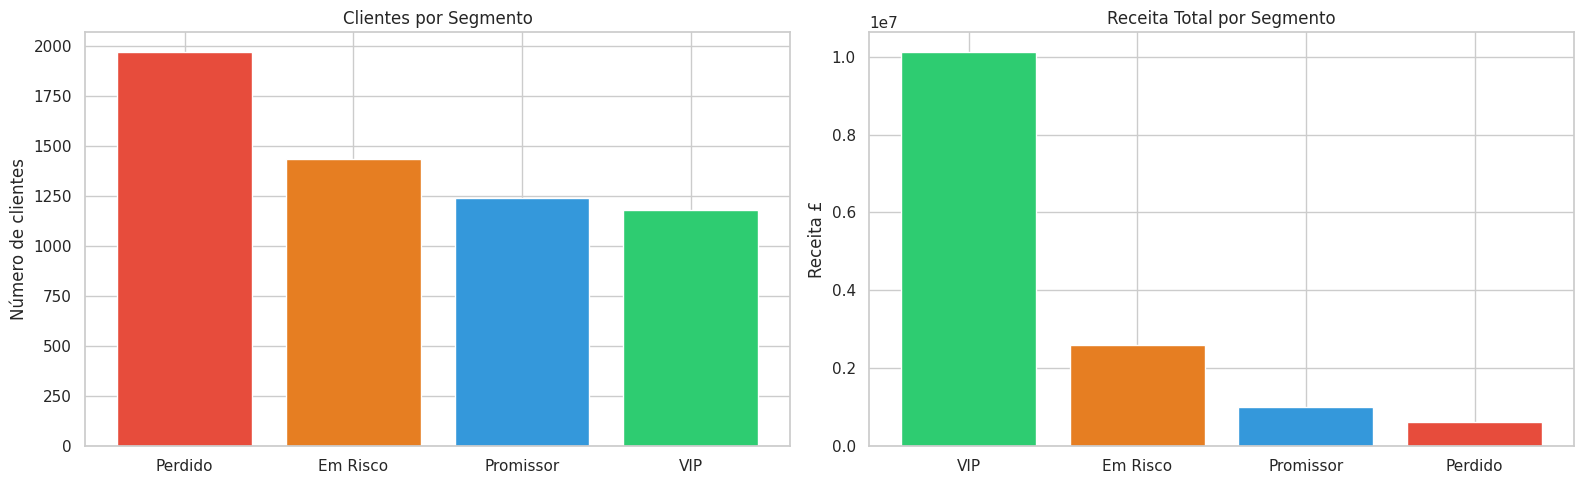


Perfil dos segmentos:
           Clientes  Recency_media  Frequency_media  Monetary_media  Receita_total  Pct_Receita
Segmento                                                                                       
Em Risco       1432         226.64             5.08         1813.29     2596629.46        18.12
Perdido        1968         393.50             1.38          310.36      610793.45         4.26
Promissor      1237          28.55             3.00          806.90      998139.25         6.96
VIP            1179          27.12            18.86         8589.31    10126800.92        70.66


In [8]:
rfm_scaled, scaler_seg = scale_features(rfm_log)
kmeans = train_kmeans(rfm_scaled, n_clusters=4)
rfm = assign_segments(rfm, kmeans, rfm_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Clientes por segmento
contagem = rfm['Segmento'].value_counts()
axes[0].bar(contagem.index, contagem.values,
            color=[CORES[s] for s in contagem.index])
axes[0].set_title('Clientes por Segmento')
axes[0].set_ylabel('Número de clientes')

# Receita por segmento
receita = rfm.groupby('Segmento')['Monetary'].sum().sort_values(ascending=False)
axes[1].bar(receita.index, receita.values,
            color=[CORES[s] for s in receita.index])
axes[1].set_title('Receita Total por Segmento')
axes[1].set_ylabel('Receita £')

plt.tight_layout()
plt.show()

print("\nPerfil dos segmentos:")
print(segment_report(rfm).to_string())

## 🔮 Predição de Churn — Random Forest

Com os segmentos definidos, criamos um modelo supervisionado para
**prever quais clientes estão em risco de churn**.

O label foi engenheirado a partir dos segmentos:
- **Churn = 1** → Em Risco + Perdido (sumiu há muito tempo)
- **Churn = 0** → VIP + Promissor (ativo recentemente)

Dois modelos foram comparados:

| Modelo | Acurácia | ROC-AUC |
|--------|----------|---------|
| Regressão Logística (baseline) | 93% | 0.9846 |
| **Random Forest** | **98%** | **0.9993** |

O **Random Forest** foi escolhido como modelo final.

---

In [9]:
rfm = create_churn_label(rfm)
X, y = prepare_features(rfm)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scaled, X_test_scaled, scaler_pred = scale_pred(X_train, X_test)
rf = train_model(X_train_scaled, y_train)

print("RANDOM FOREST — Resultado:")
print('='*50)
metrics = evaluate_model(rf, X_test_scaled, y_test)

RANDOM FOREST — Resultado:
Resultado do modelo:
              precision    recall  f1-score   support

       Ativo       0.98      0.98      0.98       484
       Churn       0.99      0.99      0.99       680

    accuracy                           0.98      1164
   macro avg       0.98      0.98      0.98      1164
weighted avg       0.98      0.98      0.98      1164

ROC-AUC: 0.9993
